# Student Performance Dataset — Exploratory Data Analysis

**Dataset:** Students Performance in Exams  
**Rows:** 1,000 | **Columns:** 8  
**Goal:** Understand how demographic factors influence student exam scores.

---

## Questions

| # | Question |
|---|----------|
| Q1 | **Distribution** — How are exam scores spread across the student population? |
| Q2 | **Outliers** — Are there students who perform significantly worse than the rest? |
| Q3 | **Categorical Impact** — Do parental education and test preparation courses affect scores? |
| Q4 | **Correlation** — Does strong performance in one subject predict performance in others? |
| Q5 | **Gender Gap** — How does student performance vary by gender across subjects? |

---

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titlepad": 12,
})

## 2. Load the Dataset

In [2]:
df = pd.read_csv('./dataset/StudentsPerformance.csv')


print(f"Shape: {df.shape}")
df.head(10)

Shape: (1000, 8)


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


## 3. Data Understanding

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [4]:
df.describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


## 4. Data Cleaning

In [5]:
# Missing Values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

# Duplicates
n_dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")

# Rename Column
df.columns = [c.replace(' ', '_').replace('/', '_') for c in df.columns]

# Add new Column
df['total_score']   = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3

print("\n✅ Data cleaning complete. New features: total_score, average_score")
df.head(5)

Missing values per column:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Duplicate rows: 0

✅ Data cleaning complete. New features: total_score, average_score


,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


---
## Q1. Distribution — How are exam scores spread across the student population?

**Hypothesis:** If the exams are well-designed, scores should follow a roughly normal (bell-shaped) distribution centred around 65–70.

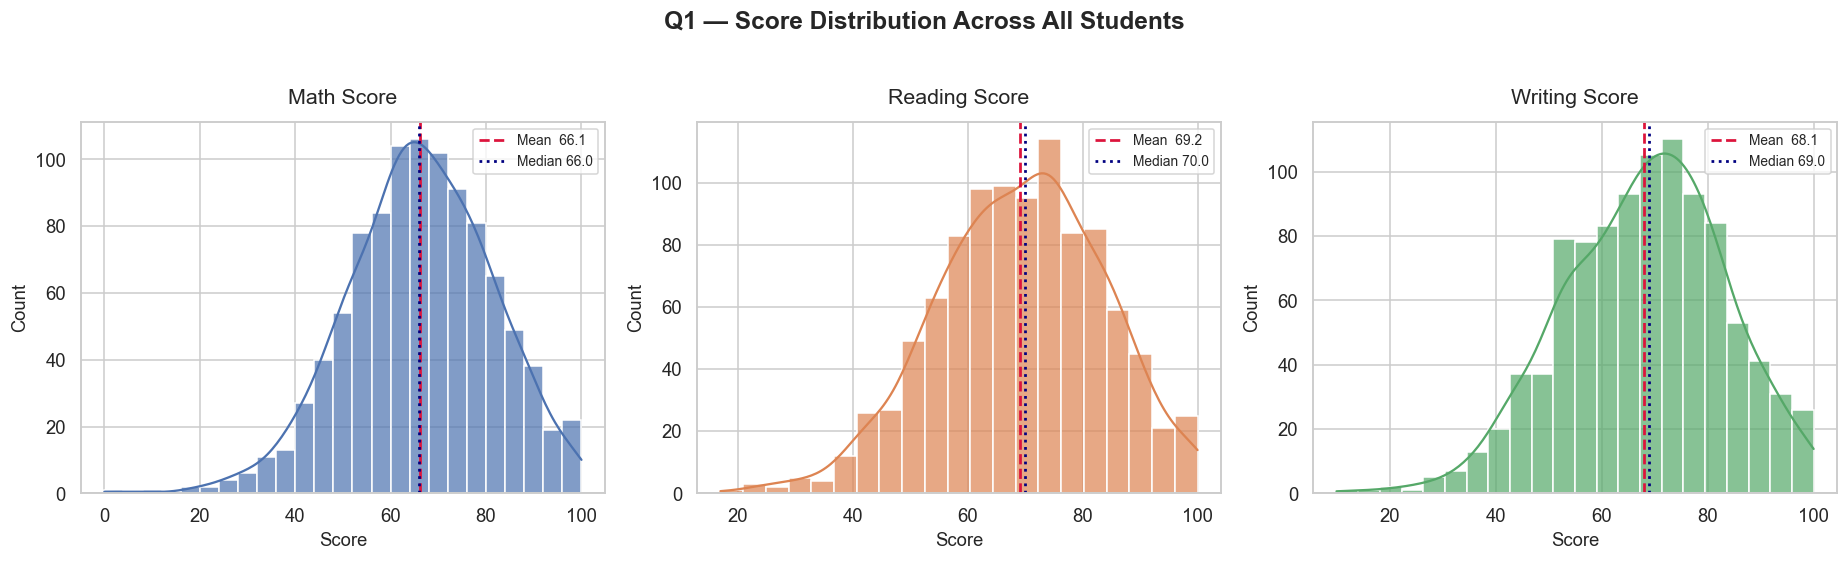

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Q1 — Score Distribution Across All Students", fontsize=16, fontweight='bold', y=1.02)

score_cols   = ['math_score', 'reading_score', 'writing_score']
score_titles = ['Math Score', 'Reading Score', 'Writing Score']
colours      = ['#4C72B0', '#DD8452', '#55A868']

for ax, col, title, colour in zip(axes, score_cols, score_titles, colours):
    sns.histplot(df[col], kde=True, ax=ax, color=colour, alpha=0.7, edgecolor='white')
    ax.axvline(df[col].mean(),   color='crimson', linestyle='--', linewidth=1.8, label=f'Mean  {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='navy',    linestyle=':',  linewidth=1.8, label=f'Median {df[col].median():.1f}')
    ax.set_title(title)
    ax.set_xlabel("Score")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Conclusion — Q1

- All three score distributions are **approximately bell-shaped (normal)**, confirming the exams are well-calibrated and not overly easy or difficult.
- **Reading and Writing** scores (mean ≈ 69 and 68) are slightly higher on average than **Math** scores (mean ≈ 66), suggesting Math is marginally harder for this cohort.
- The near-identical mean and median values confirm the distributions are **roughly symmetric** with minimal skew — neither dominated by a cluster of very high nor very low scorers.

---
## Q2. Outliers — Are there students who perform significantly worse than the rest?

**Hypothesis:** A small group of students will score unusually low (well below Q1 − 1.5×IQR), representing possible at-risk learners.

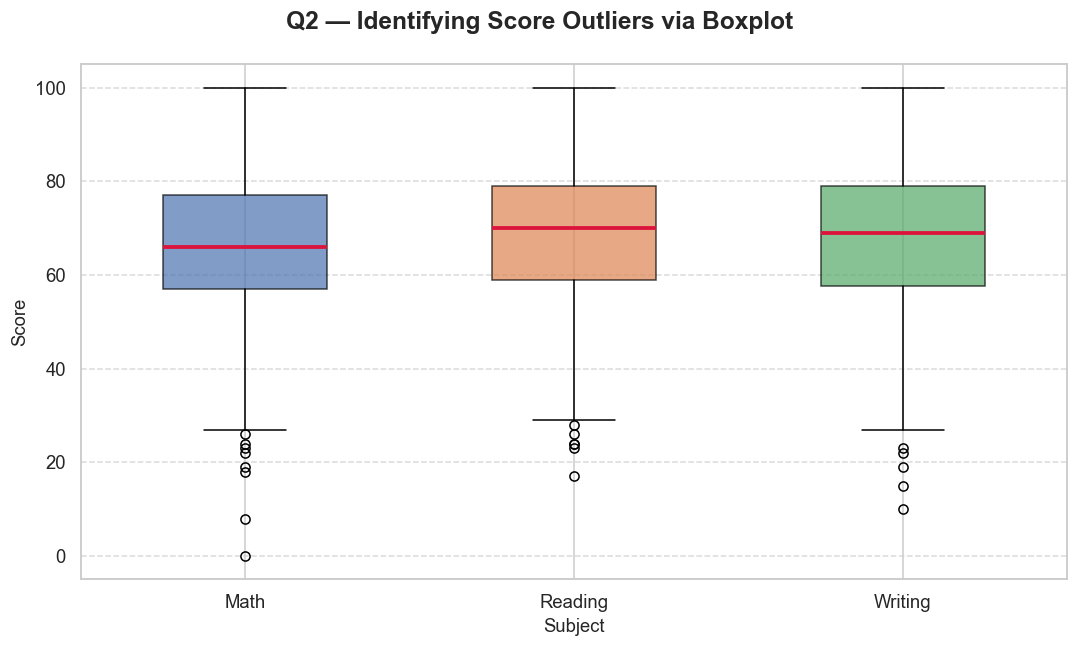

IQR-based outlier counts (below lower fence):
  math_score           lower fence = 27  |  outliers = 8
  reading_score        lower fence = 29  |  outliers = 6
  writing_score        lower fence = 26  |  outliers = 5


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle("Q2 — Identifying Score Outliers via Boxplot", fontsize=16, fontweight='bold')

bp = ax.boxplot(
    [df['math_score'], df['reading_score'], df['writing_score']],
    labels=['Math', 'Reading', 'Writing'],
    patch_artist=True,
    notch=False,
    widths=0.5,
    medianprops=dict(color='crimson', linewidth=2.5)
)

box_colours = ['#4C72B0', '#DD8452', '#55A868']
for patch, colour in zip(bp['boxes'], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

ax.set_ylabel("Score")
ax.set_xlabel("Subject")
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ── IQR-based outlier count ────────────────────────────────────────────────
print("IQR-based outlier counts (below lower fence):")
for col in ['math_score', 'reading_score', 'writing_score']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    n_out = (df[col] < lower).sum()
    print(f"  {col:<20} lower fence = {lower:.0f}  |  outliers = {n_out}")

### Conclusion — Q2

- Boxplots reveal **a small number of outliers on the lower end** for all three subjects, visible as dots below each whisker.
- Using the IQR rule (lower fence = Q1 − 1.5×IQR), the **minimum non-outlier Math score** is approximately **27**, meaning students scoring below that point are statistically unusual underperformers.
- The absence of upper outliers suggests there is **no ceiling effect** — top students are not clustered at 100%.
- These lower outliers may represent students facing external challenges (language barriers, absenteeism, etc.) and could be candidates for targeted academic support.

---
## Q3. Categorical Impact — Do parental education and test-prep courses affect scores?

**Hypothesis:** Students whose parents hold higher-level degrees will score higher, and completing a test-preparation course will provide an additional boost.

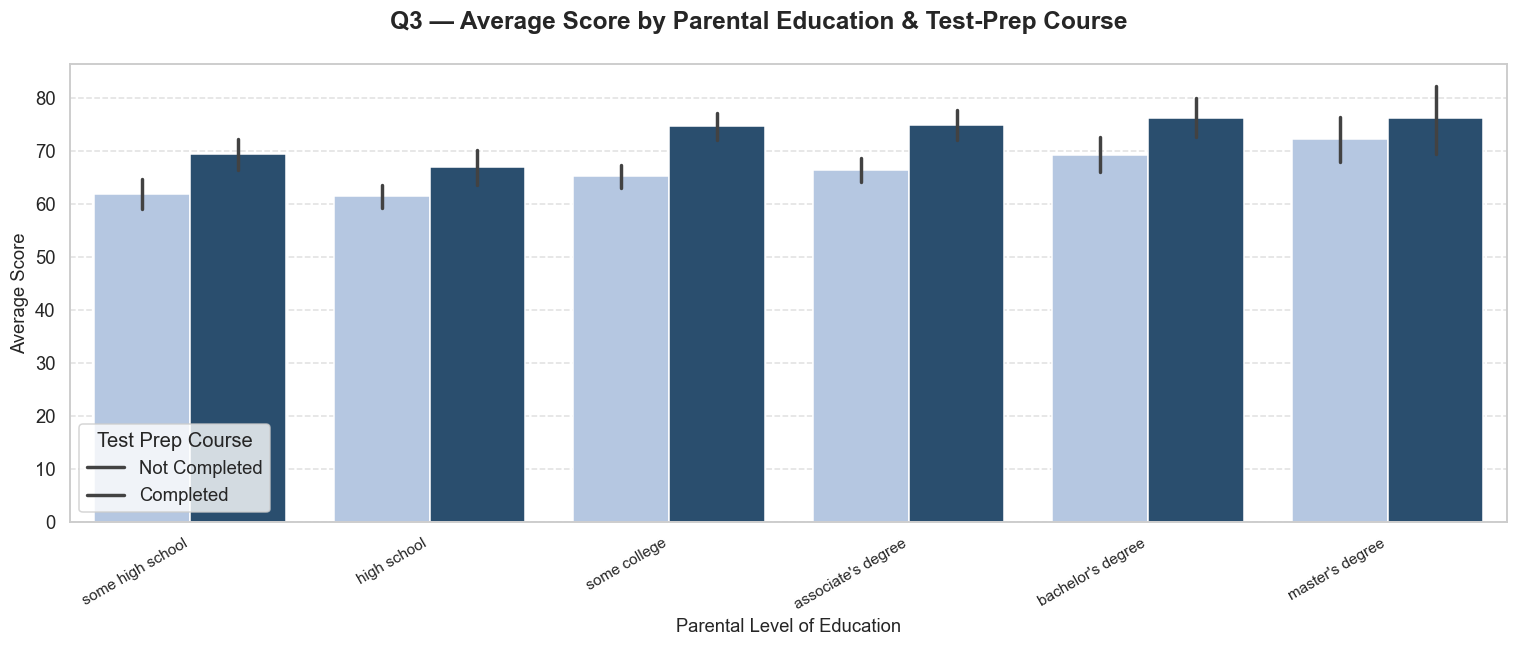

In [8]:
edu_order = [
    "some high school", "high school",
    "some college", "associate's degree",
    "bachelor's degree", "master's degree"
]

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Q3 — Average Score by Parental Education & Test-Prep Course", fontsize=16, fontweight='bold')

sns.barplot(
    data=df,
    x='parental_level_of_education',
    y='average_score',
    hue='test_preparation_course',
    order=edu_order,
    palette={'none': '#AEC6E8', 'completed': '#1F4E79'},
    ax=ax
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=10)
ax.set_xlabel("Parental Level of Education")
ax.set_ylabel("Average Score")
ax.legend(title="Test Prep Course", labels=["Not Completed", "Completed"])
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Conclusion — Q3

- **Parental education has a clear positive effect:** students with parents holding a Master's degree score on average **~10 points higher** than those whose parents did not finish high school.
- The upward trend is consistent across education levels, confirming that parental academic background is a meaningful predictor of student performance.
- **Test-preparation courses provide a consistent and significant boost** of approximately **5–8 points** across every parental education level.
- Notably, students who completed the prep course AND have highly-educated parents achieve the highest average scores, suggesting these factors are **complementary** rather than redundant.

---
## Q4. Correlation — Does strong performance in one subject predict performance in others?

**Hypothesis:** Reading and Writing will be very strongly correlated (> 0.90) because they share similar cognitive skills; Math will correlate more weakly with both.

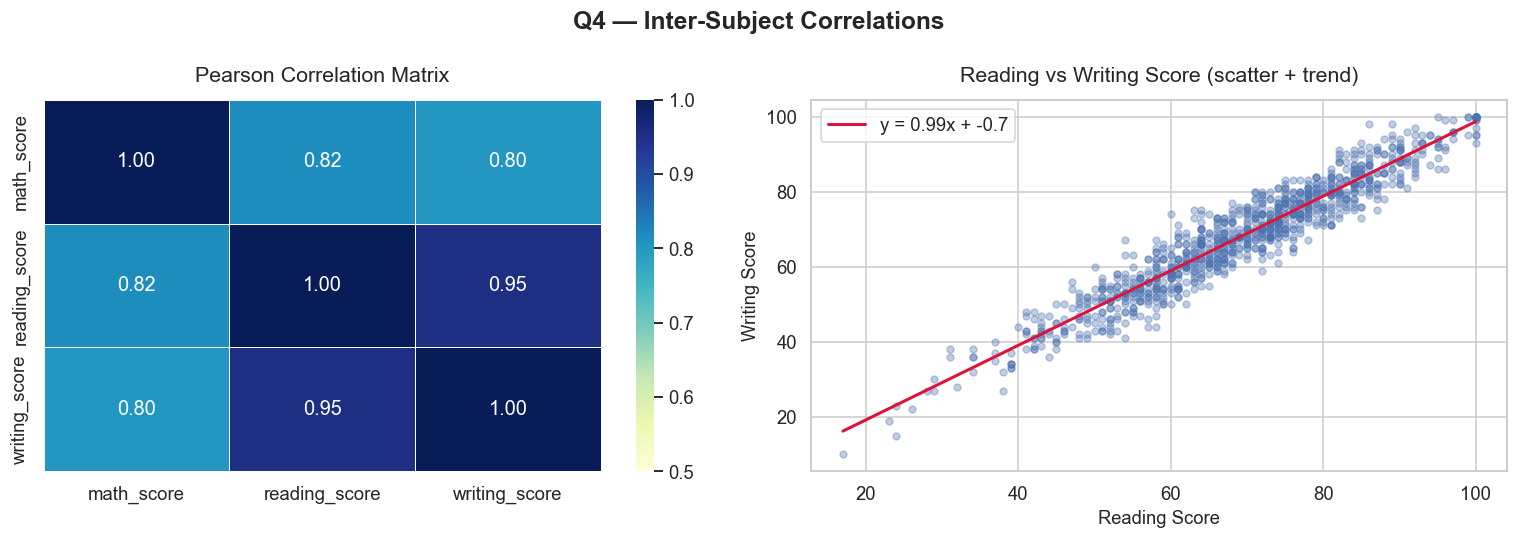

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Q4 — Inter-Subject Correlations", fontsize=16, fontweight='bold')

# Correlation heatmap 
corr = df[['math_score', 'reading_score', 'writing_score']].corr()
sns.heatmap(
    corr, ax=axes[0],
    annot=True, fmt='.2f', cmap='YlGnBu',
    vmin=0.5, vmax=1.0, linewidths=0.5,
    annot_kws={"size": 13}
)
axes[0].set_title("Pearson Correlation Matrix")

# Scatter plot: Reading vs Writing
axes[1].scatter(df['reading_score'], df['writing_score'],
                alpha=0.35, s=20, color='#4C72B0')
m, b = np.polyfit(df['reading_score'], df['writing_score'], 1)
x_line = np.linspace(df['reading_score'].min(), df['reading_score'].max(), 200)
axes[1].plot(x_line, m*x_line + b, color='crimson', linewidth=2, label=f'y = {m:.2f}x + {b:.1f}')
axes[1].set_xlabel("Reading Score")
axes[1].set_ylabel("Writing Score")
axes[1].set_title("Reading vs Writing Score (scatter + trend)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Conclusion — Q4

- **Reading ↔ Writing correlation (r ≈ 0.95):** Extremely strong — nearly all variation in Writing scores can be explained by Reading ability, confirming these two skills are deeply intertwined.
- **Math ↔ Reading and Math ↔ Writing (r ≈ 0.82 and 0.80):** Strong but meaningfully lower, indicating that mathematical talent is a somewhat independent skill set while still sharing general academic aptitude.
- The scatter plot's tight clustering around the trend line visually confirms the near-linear Reading–Writing relationship, with very few deviating data points.
- **Practical implication:** A student who struggles in Reading is very likely to also struggle in Writing, allowing teachers to address both deficits simultaneously.

---
## Q5. Gender Gap — How does student performance vary by gender across subjects?

**Hypothesis:** Female students will outperform male students in Reading and Writing, while male students may have a slight edge in Math.

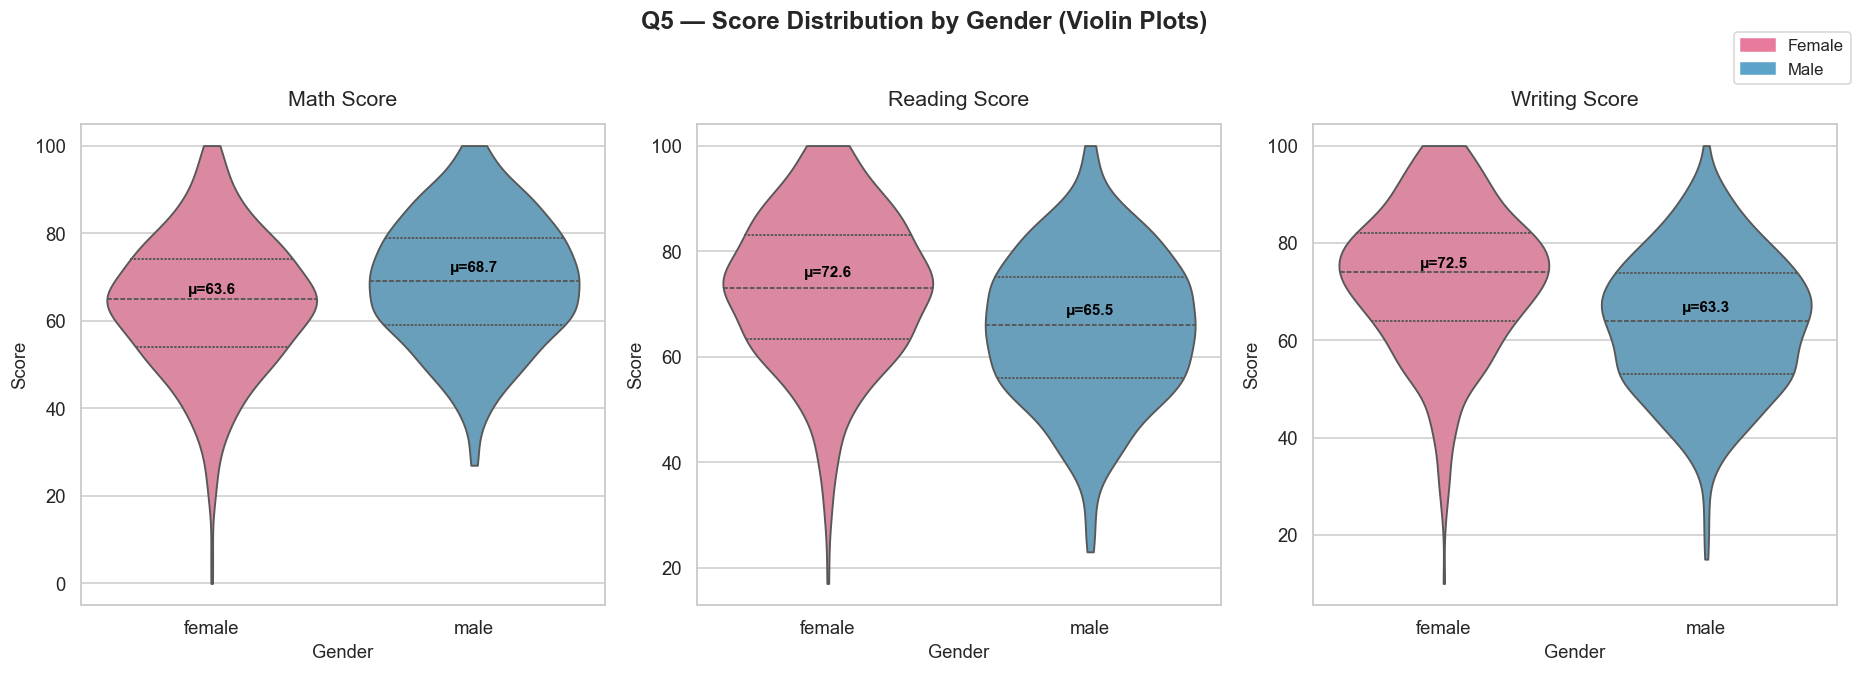


Mean scores by gender:
        math_score  reading_score  writing_score  average_score
gender                                                         
female       63.63          72.61          72.47          69.57
male         68.73          65.47          63.31          65.84


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Q5 — Score Distribution by Gender (Violin Plots)", fontsize=16, fontweight='bold', y=1.02)

score_cols   = ['math_score', 'reading_score', 'writing_score']
score_titles = ['Math Score', 'Reading Score', 'Writing Score']
palette      = {'female': '#E87B9C', 'male': '#5BA3C9'}

for ax, col, title in zip(axes, score_cols, score_titles):
    sns.violinplot(
        ax=ax, data=df,
        x='gender', y=col,
        hue='gender', palette=palette,
        legend=False, inner='quartile',
        cut=0
    )
    # annotate means
    for i, gender in enumerate(['female', 'male']):
        mu = df[df['gender'] == gender][col].mean()
        ax.text(i, mu + 2.5, f'μ={mu:.1f}', ha='center', fontsize=10, fontweight='bold', color='black')

    ax.set_title(title)
    ax.set_xlabel("Gender")
    ax.set_ylabel("Score")

# shared legend
legend_patches = [
    mpatches.Patch(color='#E87B9C', label='Female'),
    mpatches.Patch(color='#5BA3C9', label='Male')
]
fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.0, 1.0), fontsize=11)
plt.tight_layout()
plt.show()

# Mean comparison table
print("\nMean scores by gender:")
print(df.groupby('gender')[['math_score','reading_score','writing_score','average_score']].mean().round(2))

### Conclusion — Q5

- **Math:** Male students hold a slight advantage (mean ≈ 68.7 vs 63.6 for female), and the violin plot shows their distribution is more concentrated in the upper-middle range.
- **Reading:** Female students outperform male students by approximately **5 points** (mean ≈ 72.6 vs 65.5), and their distribution is visibly shifted upward.
- **Writing:** The gender gap in Writing is the largest — female students score roughly **7–8 points higher** on average (mean ≈ 72.5 vs 63.3), consistent with research showing girls tend to develop written communication skills earlier.
- The violin shapes reveal that **both genders produce occasional very low scorers**, but the bulk of female scores in verbal subjects cluster notably higher than males.
- **Overall:** There is no single dominant gender — each gender has relative strengths, reinforcing that targeted instructional strategies by subject and gender can meaningfully improve outcomes.

---
## Summary of Findings

| Research Question | Key Finding |
|---|---|
| **Q1 Distribution** | All three score distributions are approximately normal; Math scores are slightly lower than Reading/Writing. |
| **Q2 Outliers** | A small set of extreme low-scorers exists across all subjects; no significant high-end outliers detected. |
| **Q3 Categorical Impact** | Higher parental education and test-prep course completion each independently boost average scores by ~5–10 points. |
| **Q4 Correlation** | Reading–Writing are very strongly correlated (r ≈ 0.95); Math correlates moderately (r ≈ 0.81) with verbal subjects. |
| **Q5 Gender Gap** | Male students edge ahead in Math; female students significantly outperform in Reading and Writing. |

> **Data source:** [Kaggle — Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)